In [2]:
import subprocess
import sys

# 1. Colocamos apenas os pacotes externos em uma lista
pacotes = ["pandas", "numpy", "matplotlib", "seaborn"]

print("Verificando as bibliotecas necessárias...\n")

# 2. O laço 'for' vai passar por cada pacote da lista
for pacote in pacotes:
    try:
        # Tenta importar o pacote pelo nome (usando uma função especial para textos)
        __import__(pacote)
        print(f"✅ {pacote} já estava instalado.")
        
    except ImportError:
        # Se der erro, instala automaticamente
        print(f"⏳ {pacote} não encontrado. Instalando agora...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pacote])
        print(f"✅ {pacote} instalado com sucesso!")

print("\nTodas as dependências estão prontas!")

# 3. Agora importamos todas elas com seus apelidos clássicos para usar no código, incluindo o random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Importa o warnings e pedimos para ignorar os avisos visuais
import warnings
warnings.filterwarnings('ignore')


Verificando as bibliotecas necessárias...

✅ pandas já estava instalado.
✅ numpy já estava instalado.
✅ matplotlib já estava instalado.
✅ seaborn já estava instalado.

Todas as dependências estão prontas!


# Leitura do arquivo

Carregamento do Dataset do instagram.

- Os dados foram retirados da plataforma  Kaggle.

In [3]:
# Leitura dos dados do arquivo Instagram_Analytics.csv

df = pd.read_csv ("Instagram_Analytics.csv")
df.head()


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [4]:
# Informações sobre a tabela

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

- A tabela não apresenta valores ausentes.
- A tabela apresenta o Dtype corretamente distribuído.

## Verificando a coluna "content_category"

Identificar as categorias para verificar quais nichos a agência de marketing terá em mãos para trabalhar.

In [5]:
# Quantidade de postagem para cada categoria.

df['content_category'].value_counts()

content_category
Photography    3035
Fashion        3034
Technology     3025
Lifestyle      3017
Food           3010
Fitness        3004
Music          3003
Travel         2968
Beauty         2953
Comedy         2950
Name: count, dtype: int64

- A base de dados está bem balanceada, ou seja, nenhuma categoria terá vantagens por ter mais dados.

## Qual dessas categorias tem o melhor desempenho?

Para está pergunta vamos utilizar o recurso groupby, e calcular a média de engajamento e curtidas de cada categoria.

In [6]:
# Agrupando as categorias rate e likes

desempenho_categorias = df.groupby('content_category')[['engagement_rate','likes']].mean()

# Ordenar a tabela, para mostrar as maiores taxas

desempenho_categorias = desempenho_categorias.sort_values(by='engagement_rate', ascending=False)

# exibir o resultado

desempenho_categorias

,engagement_rate,likes
content_category,,
Music,0.042808,292.132867
Fitness,0.042720,289.139481
Fashion,0.042615,296.815425
Beauty,0.042197,288.440230
Food,0.042078,287.629900
Technology,0.042023,277.763967
Comedy,0.041854,289.001356
Travel,0.041677,279.374663
Lifestyle,0.041646,285.744448


- Podemos observar que Music, fitness e Fashion geram mais interações atualmente no instagram.

## Visualização dos dados

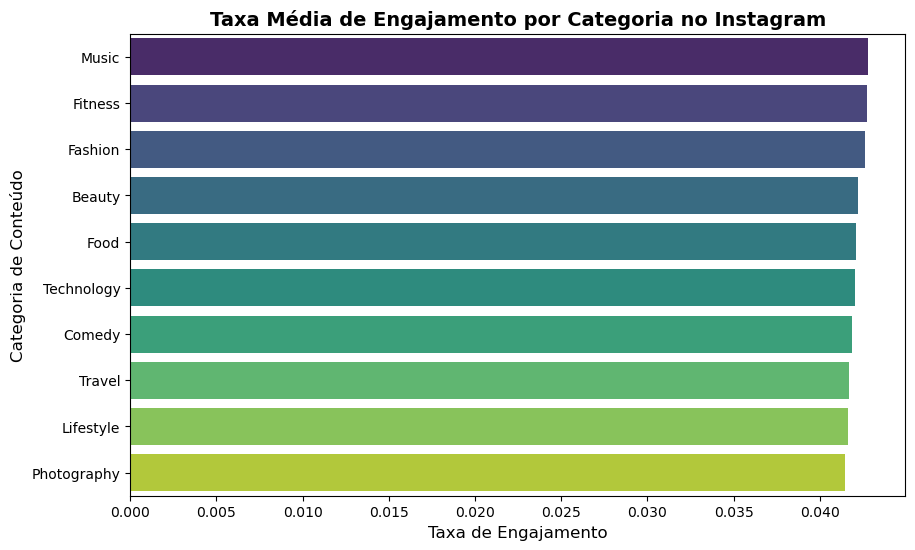

In [21]:
#GARANTIR QUE OS DADOS ESTEJAM NA ORDEM.
desempenho_categorias = desempenho_categorias.sort_values(by='engagement_rate', ascending=False)

# Tamanho da imagem do gráfico
plt.figure(figsize=(10,6))

# Gráfico de barra horizontal utilizando seaborn

sns.barplot(
    x=desempenho_categorias['engagement_rate'],
    y=desempenho_categorias.index,
    hue=desempenho_categorias.index,
    palette='viridis'
)

#Titulos do gráfico

plt.title('Taxa Média de Engajamento por Categoria no Instagram', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Engajamento', fontsize=12)
plt.ylabel('Categoria de Conteúdo', fontsize= 12)

# Salva o gráfico atual na pasta do projeto
plt.savefig('grafico_engajamento.png', bbox_inches='tight', dpi=300)

#EXIBIR

plt.show()


## Análise de Salvamento

- No instagram os saves indicam que o usuário quer consultar o conteúdo novamente, isto é valioso para a análise.

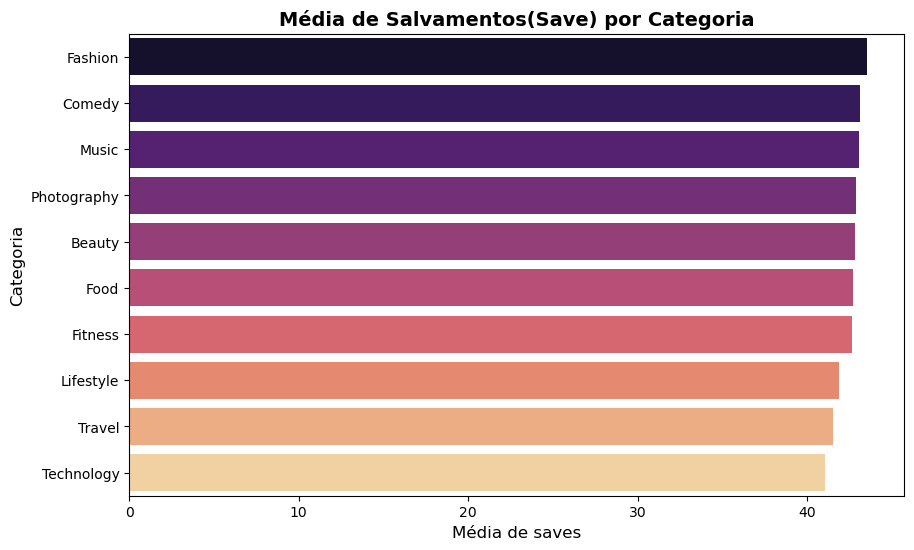

In [20]:
# GRÁFICO DE SAVES

saves_por_categoria = df.groupby('content_category')['saves'].mean().sort_values(ascending=False)
 
# Gráfico

plt.figure(figsize=(10,6))

sns.barplot(
    x=saves_por_categoria.values,
    y=saves_por_categoria.index,
    palette = 'magma'
)

plt.title('Média de Salvamentos(Save) por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Média de saves', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

# Salvando o segundo gráfico
plt.savefig('grafico_saves.png', bbox_inches='tight', dpi=300)

plt.show()


1. **Engajamento (Likes/Comentários):** Liderado por Music, Fitness e Fashion.

2. **Saves (Utilidade):** Liderado por Fashion, Comedy e Music.

- *Notamos que Fashion e Music estão fortes nas duas métricas.*

## Momento exato para agir
- Vamos verificar os dias que estas categorias (Fashion e Music) tem os melhores engajamentos.

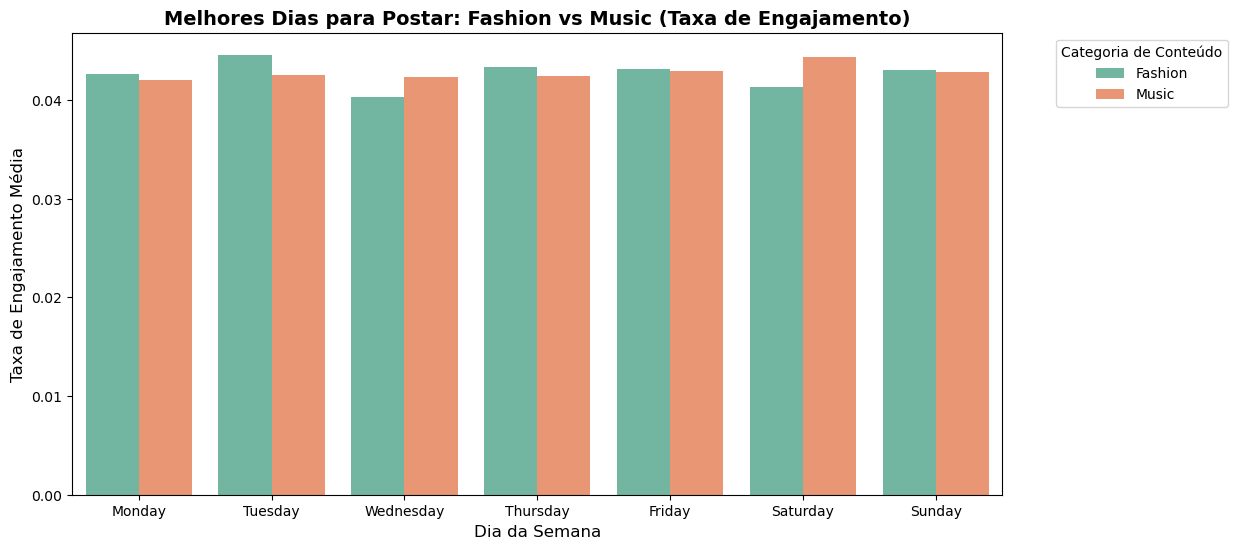

In [19]:
# Filtramos a tabela para pegar APENAS 'Fashion' e 'Music'
df_top2 = df[df['content_category'].isin(['Fashion', 'Music'])]

# Agrupamos por DUAS colunas agora: Categoria e Dia da Semana
engajamento_por_dia = df_top2.groupby(['content_category', 'day_of_week'])['engagement_rate'].mean().reset_index()

# Definimos a ordem correta dos dias da semana (para o gráfico não ficar bagunçado)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#gráfico de barras agrupado
plt.figure(figsize=(12, 6))

sns.barplot(
    data=engajamento_por_dia, 
    x='day_of_week', 
    y='engagement_rate', 
    hue='content_category', 
    order=ordem_dias,
    palette='Set2' # Uma paleta de cores excelente para comparações
)

# legenda
plt.title('Melhores Dias para Postar: Fashion vs Music (Taxa de Engajamento)', fontsize=14, fontweight='bold')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Taxa de Engajamento Média', fontsize=12)
plt.legend(title='Categoria de Conteúdo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Salvar a imagem e exibir!
plt.savefig('melhores_dias_postagem.png', bbox_inches='tight', dpi=300)
plt.show()

- 👗 **O Comportamento de Fashion:** O público focado em moda tem um pico muito claro de engajamento na Terça-feira (Tuesday). Curiosamente, na Quarta-feira o interesse despenca. Isso pode indicar que as pessoas buscam inspiração de looks ou fazem compras no início da semana.

- 🎵 **O Comportamento de Music:** O consumo de música é constante, mas tem o seu pico absoluto no Sábado (Saturday). Faz todo o sentido do mundo: é o dia em que as pessoas estão de folga, indo a festas, relaxando ou buscando entretenimento de final de semana.

## 💡 Recomendação Estratégica Final

Aprofundando a análise nas duas categorias de maior destaque (Fashion e Music), identificamos padrões de comportamento distintos durante a semana:

* **Fashion:** O pico de engajamento ocorre nas **Terças-feiras**. O meio da semana (Quarta-feira) apresenta a maior queda de interesse.
* **Music:** O engajamento atinge o seu pico máximo aos **Sábados**, alinhando-se perfeitamente com os hábitos de lazer e entretenimento de final de semana do público.

Para aumentar o alcance e o engajamento dos clientes da agência, recomendamos o seguinte calendário de ativação:
1. **Campanhas de Moda (Fashion):** Concentrar o maior volume de orçamento e postagens de alto impacto nas **Terças-feiras**.
2. **Campanhas de Música e Entretenimento:** Reservar os principais lançamentos e ações de marketing para os **Sábados**.

---

### 📊 Sobre o Autor

**Análise realizada por Pedro Bittencourt** *Estudante de Engenharia de Software*

Obrigado por acompanhar este projeto! Se quiser ver mais códigos e análises, fique à vontade para se conectar comigo:

[![GitHub](https://img.shields.io/badge/GitHub-100000?style=for-the-badge&logo=github&logoColor=white)](https://github.com/pedrobittencourtdev)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pedro-lucas-bittencourt/)

---